In [16]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict
from IPython.display import Image

# Step 1 define the state using typedict 
class BMIstate(TypedDict):

    height_m : float
    weight_kg : float

    bmi : float


def calculate_bmi(state : BMIstate ) -> BMIstate:
    weight = state['weight_kg']
    height = state['height_m']

    # calculate bmi
    bmi = weight / (height ** 2)

    return state


# define the graph 
graph = StateGraph(BMIstate)

# Step 3 :  add nodes to your graph 
graph.add_node("calculate_bmi" , calculate_bmi)


# Step 4 add edge to your graph 
graph.add_edge(START , "calculate_bmi")
graph.add_edge("calculate_bmi" , END)

# Step 5 Compile the graph 
workflow = graph.compile()



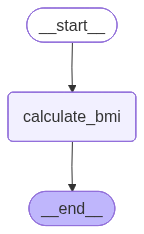

In [17]:
workflow

## Condition Workflow

In [1]:
from langgraph.graph import StateGraph , START , END 
from typing import TypedDict , Literal


c:\Users\Crashlar\anaconda3\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
# Step1: define the state 
class EquationState(TypedDict):
    a : int 
    b : int 
    c :  int 

    d :  float
    equation :  str
    result :  float


In [3]:
graph = StateGraph(EquationState)

In [4]:
def show_equation(state : EquationState):
    equation =  f"{state['a']}x^2 + {state['b']}x + {state['c']}"

    return {"equation" : equation }

def calculate_descrimination(state : EquationState):
    d = state['b']**2 - (4 * state['a'] * state['c'])

    return {"d" : d}

def real_roots(state: EquationState):

    root1 = (-state["b"] + state["d"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["d"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}

def repeated_roots(state: EquationState):

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}

def no_real_roots(state: EquationState):

    result = f'No real roots'

    return {'result': result}

def check_condition_lies(state :  EquationState) -> Literal['no_real_roots' , "repeated_roots" , "real_roots"]:
    if state['d'] == 0:
        return "repeated_roots"
    elif state['d'] > 0:
        return "real_roots"
    elif state['d'] < 0:
        return "no_real_roots"

In [5]:
graph.add_node("show_equation" , show_equation)
graph.add_node("calculate_descrimination" , calculate_descrimination)
graph.add_node("real_roots" , real_roots)
graph.add_node("repeated_roots"  , repeated_roots)
graph.add_node("no_real_roots" , no_real_roots)

graph.add_edge(START , "show_equation")
graph.add_edge("show_equation" , "calculate_descrimination")

graph.add_conditional_edges("calculate_descrimination" , check_condition_lies )
graph.add_edge("real_roots" , END)
graph.add_edge("repeated_roots" , END)
graph.add_edge("no_real_roots" , END )

worflow = graph.compile()


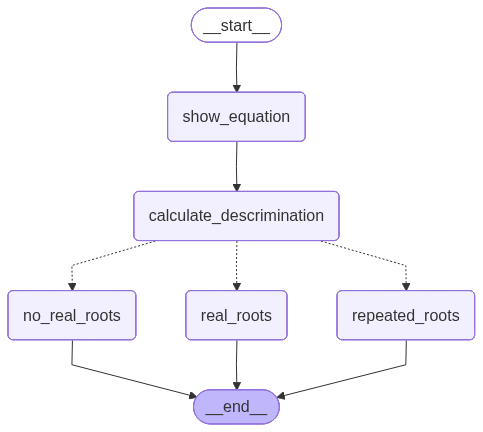

In [7]:
worflow

In [13]:
output = worflow.invoke(
    {
        "a" : 2,
        "b" : 5,
        "c" : 3
    }
)

In [14]:
output

{'a': 2,
 'b': 5,
 'c': 3,
 'd': 1,
 'equation': '2x^2 + 5x + 3',
 'result': 'The roots are -1.0 and -1.5'}